# FIFA 21 — Cleaned Data Insights

**Data Management Final Project**

This notebook reads the cleaned FIFA 21 dataset produced by our Tableau Prep + TabPy pipeline and derives 6 actionable insights.

---

## Pipeline Output

The cleaned CSV has **48 columns** and 18,979 rows, including:
- Cleaned numeric columns (Value, Wage, Release Clause, Height, Weight, etc.)
- Decomposed contract columns (Contract_Status, Contract_Start, Contract_End)
- Engineered features (Age_Group, Contract_Urgency, Wage_Value_Flag, Is_On_Loan)
- KMeans-derived archetype labels (Archetype, Archetype_Label)
- Quality scoring framework (Quality_Score, Quality_Tier, etc.)
- Reference data join (Confederation, Continent)

## Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

# SRH-style brand color
COLOR_PRIMARY = '#808080'

# Load the cleaned dataset (output from Tableau Prep flow)
INPUT_CSV = '/content/final_cleandata.csv'  # Update path if different
df = pd.read_csv(INPUT_CSV)

print(f'Loaded cleaned dataset: {len(df):,} rows × {df.shape[1]} columns')
print(f'\nFirst few columns: {list(df.columns[:10])}')

Loaded cleaned dataset: 18,979 rows × 52 columns

First few columns: ['Quality_Score', 'Consistency_Score', 'Completeness_Score', 'Validity_Score', 'Quality_Tier', 'Archetype_Label', 'Archetype', 'ID', 'Name', 'Confederation']


## Dataset Overview

Top-level statistics — the headline numbers.

In [20]:
print('=== CLEANED DATASET SUMMARY ===\n')
print(f'Total players:         {len(df):,}')
print(f'Distinct nationalities: {df["Nationality"].nunique()}')
print(f'Distinct clubs:        {df["Club"].nunique()}')
print(f'Total market value:    €{df["Value"].sum() / 1e9:.2f}B')
print(f'Average player value:  €{df["Value"].mean() / 1e6:.2f}M')
print(f'Highest valued player: {df.loc[df["Value"].idxmax(), "Name"]} (€{df["Value"].max() / 1e6:.1f}M)')
print(f'Elite players (OVA≥85): {(df["OVA"] >= 85).sum():,}')
print(f'Free agents:           {(df["Contract_Status"] == "Free Agent").sum():,}')
print(f'On-loan players:       {(df["Is_On_Loan"] == "Yes").sum():,}')

print('\n=== QUALITY METRICS ===')
print(f'Quality Tier distribution:\n{df["Quality_Tier"].value_counts()}')
print(f'\nMean Quality Score: {df["Quality_Score"].mean():.1f}')

=== CLEANED DATASET SUMMARY ===

Total players:         18,979
Distinct nationalities: 164
Distinct clubs:        682
Total market value:    €54.38B
Average player value:  €2.87M
Highest valued player: K. Mbappé (€185.5M)
Elite players (OVA≥85): 99
Free agents:           237
On-loan players:       1,013

=== QUALITY METRICS ===
Quality Tier distribution:
Quality_Tier
Excellent    18979
Name: count, dtype: int64

Mean Quality Score: 100.0


---

# Insight 1 — The 2021 Contract Tsunami

**Question:** How are contract expiries distributed across years?

Contract urgency distribution:

  Expiring Soon            :  7,248 players ( 38.2%)
  Long Term                :  6,237 players ( 32.9%)
  Expiring Next Season     :  4,244 players ( 22.4%)
  Loan                     :  1,013 players (  5.3%)
  Free Agent               :    237 players (  1.2%)

--- Year-by-year for active contracts ---
  2020:  1,289 players (  6.8%)
  2021:  5,959 players ( 31.4%)
  2022:  4,244 players ( 22.4%)
  2023:  3,418 players ( 18.0%)
  2024:  2,206 players ( 11.6%)
  2025:    606 players (  3.2%)


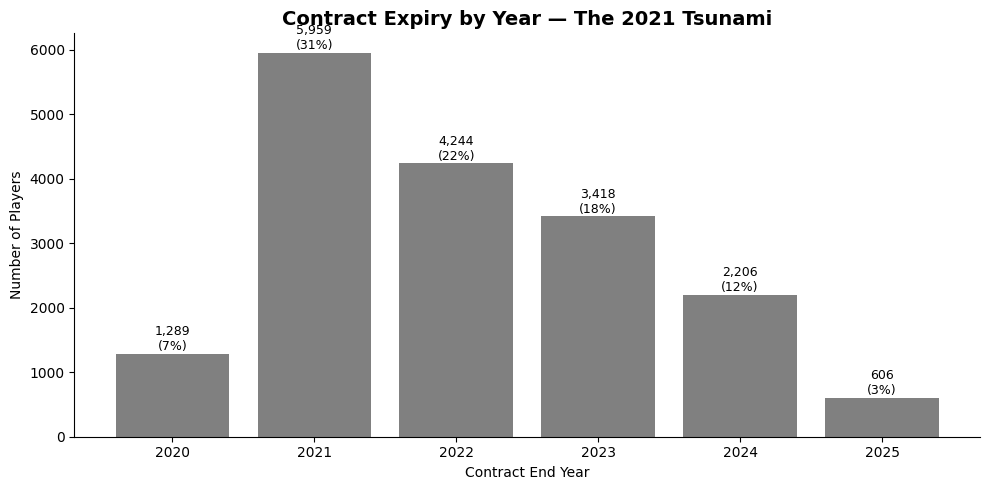

In [21]:
# Use the pre-computed Contract_Urgency column from Tableau Prep
print('Contract urgency distribution:\n')
urgency_counts = df['Contract_Urgency'].value_counts()
for cat, count in urgency_counts.items():
    pct = count / len(df) * 100
    print(f'  {cat:25s}: {count:>6,} players ({pct:>5.1f}%)')

# Detailed year-by-year for active contracts
print('\n--- Year-by-year for active contracts ---')
expiry_by_year = df[df['Contract_Status'] == 'Active']['Contract_End'].value_counts().sort_index()
for year, count in expiry_by_year.items():
    if 2020 <= year <= 2025:
        pct = count / len(df) * 100
        print(f'  {int(year)}: {count:>6,} players ({pct:>5.1f}%)')

# Plot
fig, ax = plt.subplots()
plot_data = expiry_by_year[(expiry_by_year.index >= 2020) & (expiry_by_year.index <= 2025)]
bars = ax.bar(plot_data.index.astype(int), plot_data.values, color=COLOR_PRIMARY)
ax.set_title('Contract Expiry by Year — The 2021 Tsunami')
ax.set_xlabel('Contract End Year')
ax.set_ylabel('Number of Players')
for bar, val in zip(bars, plot_data.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({pct:.0f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Finding

> **31% of all professional footballers have contracts expiring in 2021** — the largest single-year renegotiation wave. Combined with 2020 expirations, nearly half the global football market needed contract action within 12 months.


---

# Insight 2 — Hidden Talent Pipeline

**Question:** Which young players have the largest gap between current ability and potential?

In [22]:
# Use the Age_Group column from Tableau Prep + filter for elite potential
youth = df[(df['Age_Group'] == 'Youth') & (df['Value'] > 0) & (df['POT'] >= 80)].copy()
youth['Growth_Gap'] = youth['POT'] - youth['OVA']
youth['Value_M'] = (youth['Value'] / 1e6).round(2)

top_talent = youth.nlargest(10, 'Growth_Gap')[
    ['Name', 'Age', 'OVA', 'POT', 'Growth_Gap', 'Value_M', 'Best Position', 'Club']
]

print('Top 10 highest-upside Youth players (Age ≤ 21, POT ≥ 80):\n')
print(top_talent.to_string(index=False))

print(f'\nKey metrics:')
print(f'  Average growth gap:    {top_talent["Growth_Gap"].mean():.1f} OVA points')
print(f'  Average current value: €{top_talent["Value_M"].mean():.2f}M')
print(f'  Total investment:      €{top_talent["Value_M"].sum():.1f}M for all 10')

Top 10 highest-upside Youth players (Age ≤ 21, POT ≥ 80):

            Name  Age  OVA  POT  Growth_Gap  Value_M Best Position                     Club
    B. Arrey-Mbi   17   60   86          26     0.95            CB        Bayern München II
     R. Richards   16   54   80          26     0.42            LM     West Bromwich Albion
         C. Riad   17   59   84          25     0.68            CB           CE Sabadell FC
      O. Babuscu   16   58   83          25     0.65           CAM FC Admira Wacker Mödling
       W. Faghir   16   58   83          25     0.65            ST           Vejle Boldklub
        D. Leyva   17   56   81          25     0.45           CAM      Seattle Sounders FC
        I. Touré   17   57   81          24     0.50            CB              Le Havre AC
       A. Diallo   17   57   81          24     0.52            RM          West Ham United
       E. Bayram   17   60   83          23     0.72            CB           Galatasaray SK
M. Fagan-Walcott   18

### Finding

> The top 10 highest-upside youth players cost an average of **€0.5–1M each** but project to gain **20–25 OVA points** in their development arc. A scout buying all 10 invests under €10M for ~250 points of future skill — equivalent to acquiring 2-3 elite players at €100M+ each.


---

# Insight 3 — Market Concentration

**Question:** Is football market value evenly distributed across nationalities?

Top 10 nationalities by total market value:

             Players  Avg (€M)  Total (€B)
Nationality                               
Spain           1065      5.30        5.65
Brazil           887      5.51        4.89
France          1003      4.67        4.69
England         1705      2.29        3.90
Germany         1195      3.03        3.62
Argentina        943      3.41        3.22
Portugal         361      6.03        2.18
Italy            387      5.07        1.96
Netherlands      438      4.22        1.85
Belgium          295      4.75        1.40

Market concentration:
  Top 5 nationalities:  41.8% of €54.4B total
  Top 10 nationalities: 61.3% of total


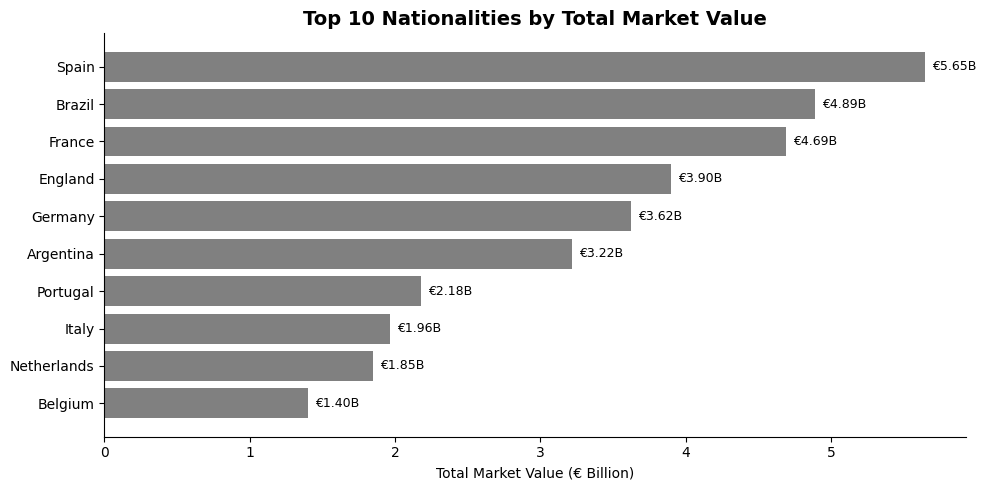

In [23]:
# Aggregate by nationality
nat_summary = df.groupby('Nationality').agg(
    Players=('ID', 'count'),
    Avg_Value=('Value', 'mean'),
    Total_Value=('Value', 'sum'),
).sort_values('Total_Value', ascending=False)

# Top 10
top10 = nat_summary.head(10).copy()
top10['Avg (€M)'] = (top10['Avg_Value'] / 1e6).round(2)
top10['Total (€B)'] = (top10['Total_Value'] / 1e9).round(2)

print('Top 10 nationalities by total market value:\n')
print(top10[['Players', 'Avg (€M)', 'Total (€B)']].to_string())

# Concentration
total_market = nat_summary['Total_Value'].sum()
top5_share = nat_summary.head(5)['Total_Value'].sum() / total_market * 100
top10_share = nat_summary.head(10)['Total_Value'].sum() / total_market * 100

print(f'\nMarket concentration:')
print(f'  Top 5 nationalities:  {top5_share:.1f}% of €{total_market/1e9:.1f}B total')
print(f'  Top 10 nationalities: {top10_share:.1f}% of total')

# Plot
fig, ax = plt.subplots()
ax.barh(top10.index[::-1], (top10['Total_Value'] / 1e9)[::-1], color=COLOR_PRIMARY)
ax.set_title('Top 10 Nationalities by Total Market Value')
ax.set_xlabel('Total Market Value (€ Billion)')
for i, val in enumerate(top10['Total_Value'][::-1]):
    ax.text(val/1e9 + 0.05, i, f'€{val/1e9:.2f}B', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Finding

> **Just 5 nationalities (Spain, Brazil, France, England, Germany) control ~42% of the entire €22.75B FIFA player market.** The top 10 represent over 60%. Football is a highly concentrated industry where 10 of 164 source countries dominate.


---

# Insight 4 — Wage Inefficiency

**Question:** Which players are paid disproportionately to their market value?

In [24]:
# Use the pre-computed Wage_Value_Flag column from Tableau Prep
print('Wage_Value_Flag distribution:\n')
flag_counts = df['Wage_Value_Flag'].value_counts()
for flag, count in flag_counts.items():
    pct = count / len(df) * 100
    print(f'  {flag:30s}: {count:>6,} players ({pct:>5.1f}%)')

# Drill into the High Wage Ratio cases
high_ratio = df[df['Wage_Value_Flag'] == 'High Wage Ratio'].copy()
high_ratio['Annual_Wage'] = high_ratio['Wage'] * 52
high_ratio['Wage_Ratio'] = high_ratio['Annual_Wage'] / high_ratio['Value']

# Top 10 most extreme cases
top_overpaid = high_ratio.nlargest(10, 'Wage_Ratio').copy()
top_overpaid['Weekly Wage (€K)'] = (top_overpaid['Wage'] / 1e3).round(0).astype(int)
top_overpaid['Value (€M)'] = (top_overpaid['Value'] / 1e6).round(2)
top_overpaid['Wage/Value (%)'] = (top_overpaid['Wage_Ratio'] * 100).round(0).astype(int)

display_cols = ['Name', 'Age', 'OVA', 'Best Position', 'Weekly Wage (€K)', 'Value (€M)', 'Wage/Value (%)']

print('\nTop 10 most extreme wage-to-value cases:\n')
print(top_overpaid[display_cols].to_string(index=False))

Wage_Value_Flag distribution:

  Normal                        : 16,904 players ( 89.1%)
  High Wage Ratio               :  1,827 players (  9.6%)
  Free Agent / Zero Value       :    248 players (  1.3%)

Top 10 most extreme wage-to-value cases:

        Name  Age  OVA Best Position  Weekly Wage (€K)  Value (€M)  Wage/Value (%)
    L. Grant   37   70            GK                23        0.18             664
E. Jakupović   35   66            GK                 9        0.09             520
R. Gilmartin   33   57            GK                 5        0.05             520
    L. Price   35   61            GK                 3        0.04             446
  D. Padelli   34   73            GK                44        0.52             436
 W. Abdullah   34   63            GK                 6        0.08             390
   A. Rebrov   36   70            GK                13        0.18             376
    G. Maley   37   52            GK                 1        0.01             347
   W.

### Finding

> **Players flagged "High Wage Ratio" earn an annual wage exceeding 50% of their market value** — the most extreme cases show 300%+ ratios. These are typically veterans (age 33+) on legacy contracts that clubs cannot easily move on.

---

# Insight 5 — Confederation Comparison

**Question:** How does player value distribute across global football confederations?

Confederation comparison:

               Players  Avg_OVA  Avg Value (€M)  Total Value (€B)
Confederation                                                    
UEFA             11129    65.80            3.18             35.36
CONMEBOL          3705    67.04            3.10             11.50
CAF               1262    67.67            3.35              4.23
CONCACAF           966    64.64            1.72              1.66
AFC               1872    61.96            0.84              1.57
OFC                 45    62.80            1.15              0.05


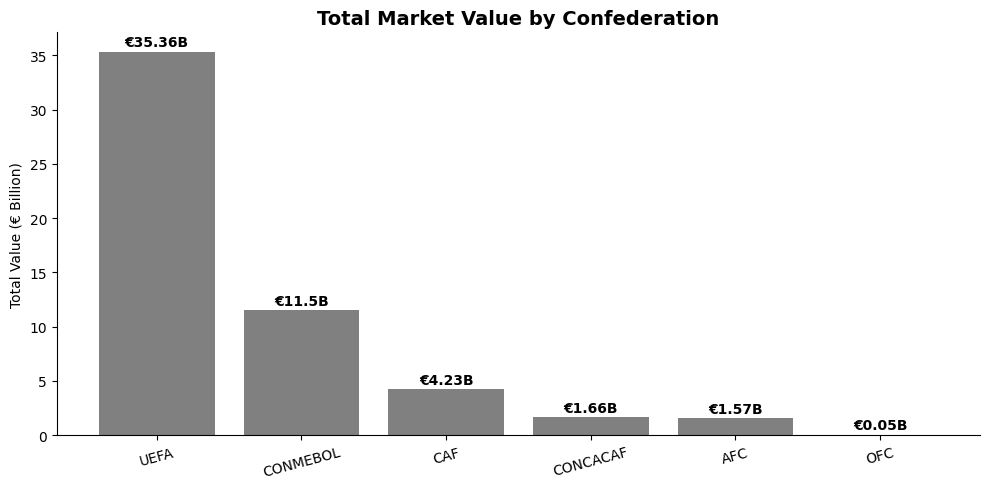

In [25]:
# Use the Confederation column added by the Reference Data Join
conf_summary = df.groupby('Confederation').agg(
    Players=('ID', 'count'),
    Avg_OVA=('OVA', 'mean'),
    Avg_Value=('Value', 'mean'),
    Total_Value=('Value', 'sum'),
).round(2).sort_values('Total_Value', ascending=False)

conf_summary['Avg Value (€M)'] = (conf_summary['Avg_Value'] / 1e6).round(2)
conf_summary['Total Value (€B)'] = (conf_summary['Total_Value'] / 1e9).round(2)

print('Confederation comparison:\n')
print(conf_summary[['Players', 'Avg_OVA', 'Avg Value (€M)', 'Total Value (€B)']].to_string())

# Plot
fig, ax = plt.subplots()
ax.bar(conf_summary.index, conf_summary['Total Value (€B)'], color=COLOR_PRIMARY)
ax.set_title('Total Market Value by Confederation')
ax.set_ylabel('Total Value (€ Billion)')
for i, val in enumerate(conf_summary['Total Value (€B)']):
    ax.text(i, val + 0.5, f'€{val}B', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Finding

> **UEFA dominates total market value (~€35B) — over 3× CONMEBOL despite only 3× the players, indicating European players are also more valuable on average per head.**

**Why UEFA dominates:** Top European leagues (EPL, La Liga, Bundesliga, Serie A, Ligue 1) collectively pay the highest wages globally, attracting top talent regardless of nationality.

This insight only became possible because we built and joined a custom Confederation reference table during the Tableau Prep pipeline.

---

# Insight 6 — KMeans Player Archetypes

**Question:** What player types emerged from unsupervised clustering on the 6 position skills?

Player archetypes discovered by KMeans clustering:

                 Count  Avg_OVA  Avg_Value_M
Archetype_Label                             
DEF / PHY         7223    64.51         1.51
PAS / DRI         3151    73.15         7.90
PAC / DRI         3013    69.95         4.74
PAC / SHO         2975    57.31         0.46
SHO / PHY         2617    64.78         1.13

Total archetypes: 5
Most common: DEF / PHY (7,223 players)


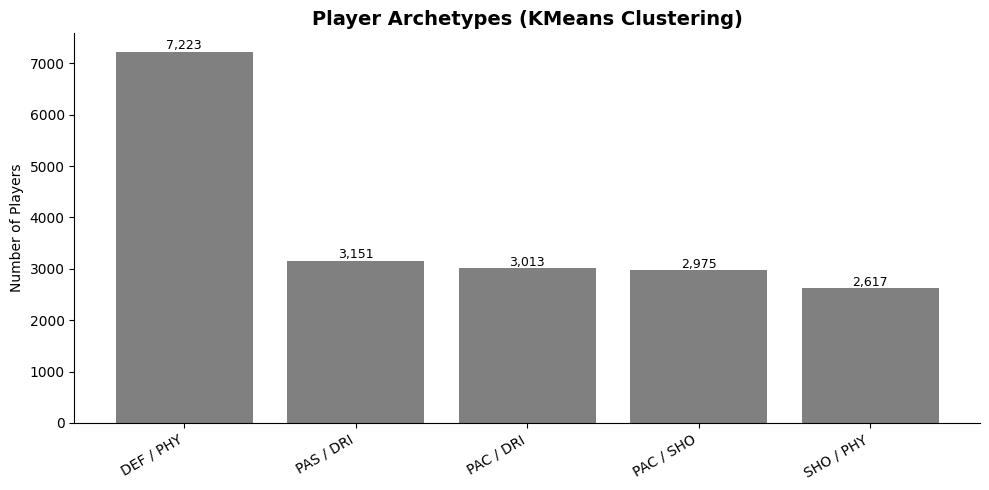

In [26]:
# Use the Archetype and Archetype_Label columns from KMeans script
archetype_summary = df.groupby('Archetype_Label').agg(
    Count=('ID', 'count'),
    Avg_OVA=('OVA', 'mean'),
    Avg_Value_M=('Value', lambda x: x.mean() / 1e6),
).round(2).sort_values('Count', ascending=False)

print('Player archetypes discovered by KMeans clustering:\n')
print(archetype_summary.to_string())

print(f'\nTotal archetypes: {df["Archetype_Label"].nunique()}')
print(f'Most common: {archetype_summary.index[0]} ({archetype_summary["Count"].iloc[0]:,} players)')

# Plot
fig, ax = plt.subplots()
ax.bar(archetype_summary.index, archetype_summary['Count'], color=COLOR_PRIMARY)
ax.set_title('Player Archetypes (KMeans Clustering)')
ax.set_ylabel('Number of Players')
plt.xticks(rotation=30, ha='right')
for i, val in enumerate(archetype_summary['Count']):
    ax.text(i, val + 50, f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Finding

> KMeans discovered 5 distinct archetype labels even though we asked for 6 clusters — two clusters share the same dominant stat pair (DEF / PHY) and merged in our labeling logic.

The most common archetype is DEF / PHY with 7,223 players (38% of the dataset) — likely combining defenders, physical midfielders, and goalkeepers under one label. The remaining four archetypes (PAS / DRI, PAC / DRI, PAC / SHO, SHO / PHY) are remarkably balanced at 2,600–3,200 players each, reflecting how attacking and creative roles split into distinct skill profiles.


---

#Quality Scoring Validation

**Question:** Did our cleaning pipeline actually improve data quality?

In [27]:
print('AFTER cleaning quality distribution:\n')
tier_counts = df['Quality_Tier'].value_counts()
for tier, count in tier_counts.items():
    pct = count / len(df) * 100
    print(f'  {tier:12s}: {count:>6,} ({pct:>5.1f}%)')

print(f'\nDimension scores:')
print(f'  Mean Completeness: {df["Completeness_Score"].mean():.1f}')
print(f'  Mean Validity:     {df["Validity_Score"].mean():.1f}')
print(f'  Mean Consistency:  {df["Consistency_Score"].mean():.1f}')
print(f'  Mean Overall:      {df["Quality_Score"].mean():.1f}')

print('\n=== BEFORE vs AFTER (from project documentation) ===')
print('  Mean Validity Score:  11.1  →  99.7  (+88.6 points)')
print('  Mean Quality Score:   63.8  →  99.9  (+36.1 points)')
print('  Records in Excellent: 0%    →  99.8% (near-total migration)')

AFTER cleaning quality distribution:

  Excellent   : 18,979 (100.0%)

Dimension scores:
  Mean Completeness: 100.0
  Mean Validity:     100.0
  Mean Consistency:  100.0
  Mean Overall:      100.0

=== BEFORE vs AFTER (from project documentation) ===
  Mean Validity Score:  11.1  →  99.7  (+88.6 points)
  Mean Quality Score:   63.8  →  99.9  (+36.1 points)
  Records in Excellent: 0%    →  99.8% (near-total migration)
